# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Business Understanding — Reframing as a Data Task**

From a data science perspective, this is a **supervised regression problem**: we want to build a predictive model where the **target variable is the sale price of a used car** and the **features are vehicle attributes** (year, make, model, mileage, condition, fuel type, transmission, drive type, etc.).

The underlying business question — *what factors make a car more or less expensive?* — translates into two technical objectives:

1. **Prediction**: Train a regression model that accurately estimates the listing price of a used vehicle given its attributes, minimizing error metrics such as RMSE and MAE.
2. **Inference**: Identify which features have the strongest positive or negative association with price (feature importance / regression coefficients), so the dealership can prioritize acquiring inventory with high-value characteristics and price vehicles competitively.

Success will be measured by a combination of (a) low out-of-sample prediction error (via cross-validation) and (b) interpretable, actionable feature importance rankings that a non-technical audience can act on.

The dataset contains **426,880 used car listings** with 18 attributes spanning vehicle specs (year, make, model, condition, cylinders, fuel, transmission, drive, type), listing metadata (price, odometer, title status, paint colour), and geography (state, region). The target variable is **price**, which is a continuous numeric value confirming this is a regression task. Key data quality concerns we anticipate include extreme price outliers, high proportions of missing values in several columns, and high cardinality in freeform text fields like `model`.

**Measuring Success:** A model with R² ≥ 0.60 and low cross-validated RMSE will be considered a good fit. Beyond raw accuracy, the coefficients of regularised linear models (Ridge/Lasso) will serve as interpretable signals for which features most strongly drive price directly answering the business question.

### Data Understanding

After considering the business understanding, we want to get familiar with our data. The steps below load the dataset, inspect its structure, quantify missing values, and visualise the distributions of key features [both numeric and categorical] to identify quality issues and inform our data preparation strategy.

**Step 1 — Load libraries and dataset**

We begin by loading the data and taking a first look at its dimensions, column types, and a sample of rows.

In [1]:
# ── Import libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Display settings ──────────────────────────────────────────────────────────
# Show all columns side-by-side without truncation
pd.set_option('display.max_columns', None)
# Format floats with comma thousands separator and 2 decimal places
pd.set_option('display.float_format', '{:,.2f}'.format)
# Apply a clean white-grid background to all seaborn charts
sns.set_theme(style='whitegrid')

# ── Load dataset ──────────────────────────────────────────────────────────────
# Read the CSV from the data/raw/ folder
df = pd.read_csv('data/raw/vehicles.csv')

# Print dimensions as a quick sanity-check
print(f"Dataset shape: {df.shape}")

# Display the first 5 rows
df.head()

Dataset shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [2]:
# df.info() prints a concise summary of the DataFrame:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

              Missing Count  Missing %
size                 306361      71.77
cylinders            177678      41.62
condition            174104      40.79
VIN                  161042      37.73
drive                130567      30.59
paint_color          130203      30.50
type                  92858      21.75
manufacturer          17646       4.13
title_status           8242       1.93
model                  5277       1.24
odometer               4400       1.03
fuel                   3013       0.71
transmission           2556       0.60
year                   1205       0.28


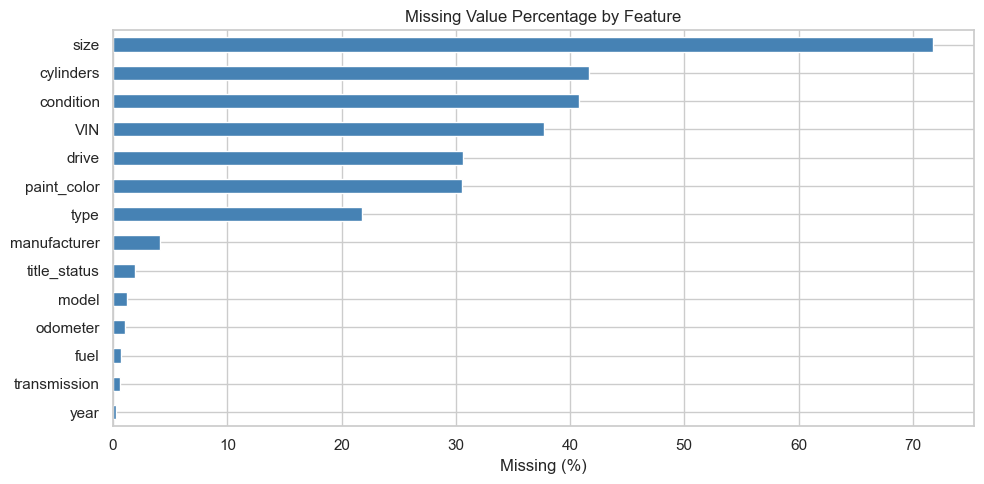

In [3]:
# ── Count missing values per column ──────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)

# Convert raw counts to percentages relative to total rows
missing_pct = (missing / len(df) * 100).round(2)

# Build a summary table with both count and percentage columns
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

# Keep only columns that actually have at least one missing value
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

# ── Visualise missing proportions as a horizontal bar chart ──────────────────
plt.figure(figsize=(10, 5))
# Plot percentage missing; .sort_values() orders bars from least to most missing
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Missing (%)')
plt.title('Missing Value Percentage by Feature')
plt.tight_layout()
plt.show()

In [4]:
# ── Descriptive statistics for key numeric columns ───────────────────────────
print("=== Descriptive Statistics (numeric columns) ===\n")
df[['price', 'year', 'odometer']].describe().round(2)

=== Descriptive Statistics (numeric columns) ===



,price,year,odometer
count,"426,880.00","425,675.00","422,480.00"
mean,"75,199.03","2,011.24","98,043.33"
std,"12,182,282.17",9.45,"213,881.50"
min,0.00,"1,900.00",0.00
25%,"5,900.00","2,008.00","37,704.00"
50%,"13,950.00","2,013.00","85,548.00"
75%,"26,485.75","2,017.00","133,542.50"
max,"3,736,928,711.00","2,022.00","10,000,000.00"


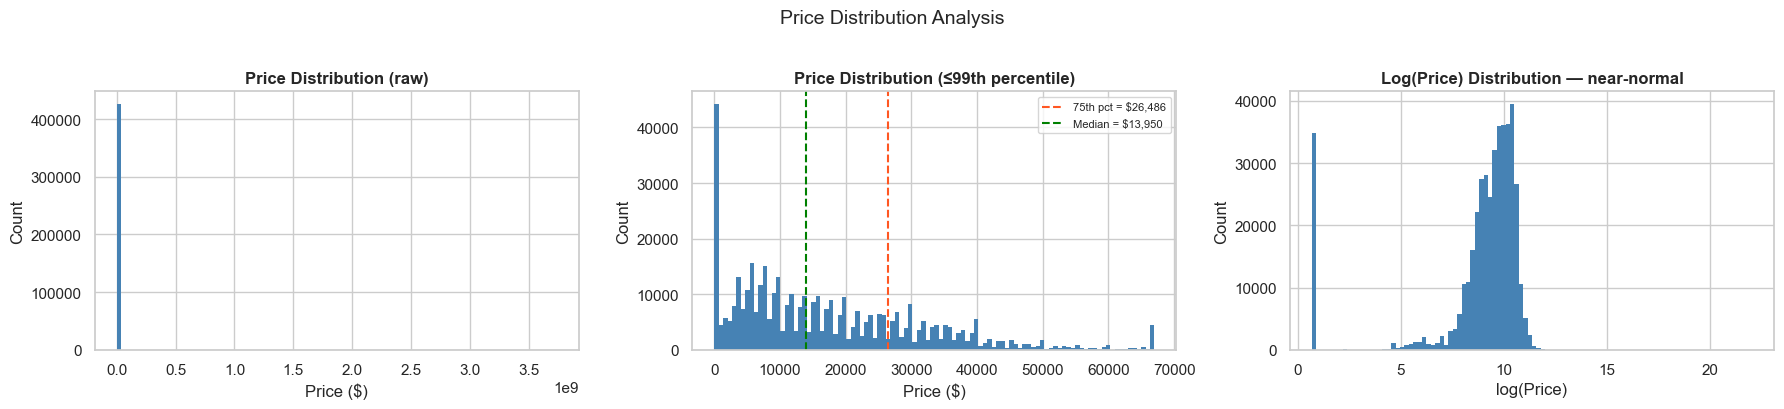

Prices = $0:          32,895
Prices > $150,000:    196
Median price:         $13,950
Mean price (raw):     $75,199  ← distorted by outliers


In [5]:
# ── Price distribution analysis — three views ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# --- Panel 1: Raw price distribution ---
# Shows the full data including extreme outliers (some prices reach $3.7B).
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Price Distribution (raw)', fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# --- Panel 2: Clipped at 99th percentile ---
# This removes the long tail so we can see the bulk of the data.
# Vertical lines mark the median and 75th percentile for understanding where most vehicle prices fall.
price_clip = df['price'].clip(upper=df['price'].quantile(0.99))
axes[1].hist(price_clip, bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(df['price'].quantile(0.75), color='#FF5722', linestyle='--', linewidth=1.5,
                label=f"75th pct = ${df['price'].quantile(0.75):,.0f}")
axes[1].axvline(df['price'].median(), color='green', linestyle='--', linewidth=1.5,
                label=f"Median = ${df['price'].median():,.0f}")
axes[1].legend(fontsize=8)
axes[1].set_title('Price Distribution (≤99th percentile)', fontweight='bold')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')

# --- Panel 3: Log-price distribution ---
# np.log1p(x) computes log(1 + x), which is safe when x = 0.
# Log-transforming price converts the right-skewed distribution into an approximately normal one
# We predict log(price) and exponentiate the output to get dollar estimates.
axes[2].hist(np.log1p(df['price'].clip(lower=1)), bins=100, color='steelblue', edgecolor='none')
axes[2].set_title('Log(Price) Distribution — near-normal', fontweight='bold')
axes[2].set_xlabel('log(Price)')
axes[2].set_ylabel('Count')

plt.suptitle('Price Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary counts of problematic prices ─────────────────────────────────────
print(f"Prices = $0:          {(df['price'] == 0).sum():,}")
print(f"Prices > $150,000:    {(df['price'] > 150_000).sum():,}")
print(f"Median price:         ${df['price'].median():,.0f}")
print(f"Mean price (raw):     ${df['price'].mean():,.0f}  ← distorted by outliers")

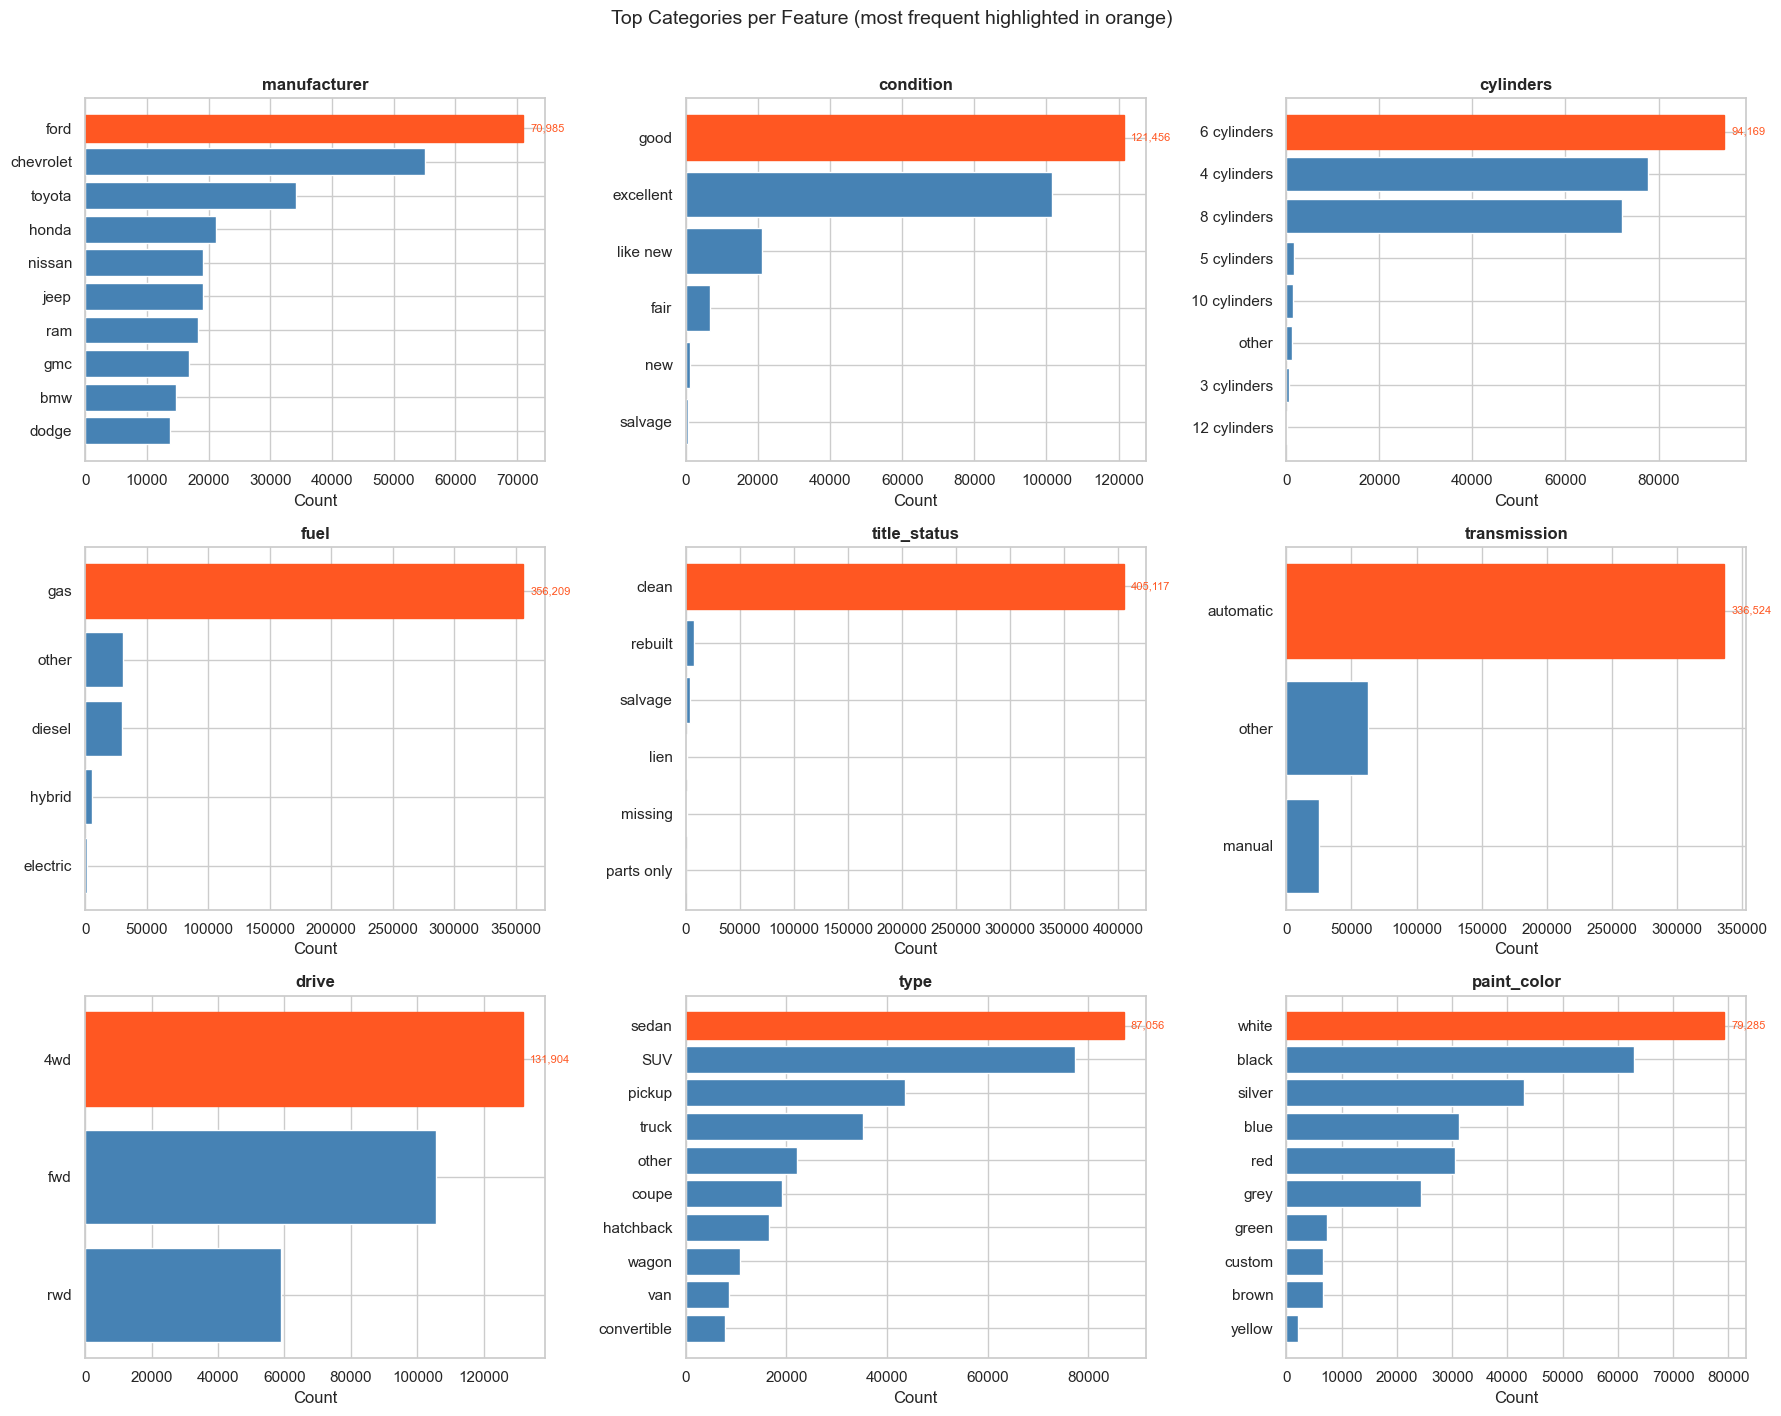

In [6]:
# ── Categorical feature distributions (top-10 per column) ────────────────────
# Understanding which categories dominate helps us decide:
#   (a) whether rare categories need to be collapsed into an 'other' bucket
#   (b) which categories might have enough data to provide meaningful signal
cat_eda_cols = ['manufacturer', 'condition', 'cylinders', 'fuel',
                'title_status', 'transmission', 'drive', 'type', 'paint_color']

# Create a 3×3 grid of subplots [one per categorical feature]
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten() 

for i, col in enumerate(cat_eda_cols):
    # Count occurrences of each category value and take the top 10
    counts = df[col].value_counts().head(10)

    # Draw horizontal bar chart (easier to read long category labels)
    bars = axes[i].barh(counts.index.astype(str), counts.values, color='steelblue')

    # Highlight the single most frequent category in orange to draw attention
    bars[0].set_color('#FF5722')

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].invert_yaxis()  

    # Annotate the top bar with its exact count value
    axes[i].annotate(f'{counts.values[0]:,}',
                     xy=(counts.values[0], 0), xytext=(5, 0),
                     textcoords='offset points', va='center',
                     fontsize=8, color='#FF5722')

plt.suptitle('Top Categories per Feature (most frequent highlighted in orange)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Data Understanding — Key Observations**

- **Price** has extreme outliers (values of \$0 and up to ~\$3.7B); these are data entry errors that must be filtered before modelling.
- **Size** (~72% missing), **cylinders** (~42%), **condition** (~41%), and **drive** (~31%) have very high missingness requiring a deliberate imputation strategy.
- **VIN** is a unique identifier with no predictive value. It will be dropped.
- **Year** and **odometer** are the primary numeric predictors. Their distributions are skewed and their relationship with price is expected to be nonlinear.
- **Manufacturer** and **type** show strong category variation. Rare categories will be grouped to avoid high-cardinality one-hot explosion.
- The majority of listings are **gas**, **automatic**, **sedan/SUV** vehicles. This is consistent with the US used-car market.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

**Step 1 — Drop irrelevant columns and filter extreme price outliers**

`id`, `VIN`, and `region` carry no predictive signal for price. We also filter prices to a realistic range (\$500 – \$150,000) to remove data entry errors and scrap/auction anomalies.

In [7]:
# ── Drop identifier and geography columns ────────────────────────────────────
df_clean = df.drop(columns=['id', 'VIN', 'region'])

# ── Filter price to a realistic range ────────────────────────────────────────
# Lower bound $500  : removes $0 listings (likely scrap/placeholder entries)
# Upper bound $150k : removes auction anomalies and data entry errors
# Vehicles outside this range represent < 5% of rows
df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 150_000)]
print(f"Rows after price filter: {len(df_clean):,}  "
      f"(removed {len(df) - len(df_clean):,} rows)")

# ── Drop 'size' column ────────────────────────────────────────────────────────
# 'size' is missing in ~72% of rows 
df_clean = df_clean.drop(columns=['size'])
print(f"Columns remaining: {df_clean.shape[1]}")

Rows after price filter: 384,590  (removed 42,290 rows)
Columns remaining: 14


**Step 2 — Handle missing values**

- **Numeric** (`year`, `odometer`): impute with median.
- **Categorical** with moderate missingness (`condition`, `cylinders`, `drive`, `paint_color`, `type`, `fuel`, `title_status`, `transmission`, `manufacturer`, `model`): impute with `'unknown'` — this preserves rows and lets the model learn that missingness itself may carry information.

In [8]:
# ── Impute numeric columns with the column median ────────────────────────────
# We use the median (not mean) because price and odometer are right-skewed
for col in ['year', 'odometer']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# ── Impute categorical columns with the string 'unknown' ─────────────────────
# Strategy: instead of dropping rows with missing categoricals (which would lose
# too much data) or imputing with the mode (which can introduce false signal)
cat_impute_cols = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
                   'title_status', 'transmission', 'drive', 'type', 'paint_color']
for col in cat_impute_cols:
    df_clean[col] = df_clean[col].fillna('unknown')

# Confirm no nulls remain
print("Remaining nulls after imputation:")
print(df_clean.isnull().sum().sum(), "total null cells")

Remaining nulls after imputation:
0 total null cells


In [9]:
# ── Feature 1: vehicle_age ───────────────────────────────────────────────────
# Age is more interpretable than raw model year and is directly comparable across listings (a 2015 car is always the same age regardless of when we're training).
# We use the current year dynamically so ages reflect real-world depreciation
# at the actual time of analysis — avoids hardcoding a year that goes stale.
import datetime
current_year = datetime.datetime.now().year         
df_clean['vehicle_age'] = current_year - df_clean['year']

# ── Feature 2 & 3: log-transformed numeric features ─────────────────────────
# Both price and odometer are heavily right-skewed.  Taking log(1+x) (log1p)
# compresses the long tail and helps linear models assume a more linear relationship.
df_clean['log_price']    = np.log1p(df_clean['price'])
df_clean['log_odometer'] = np.log1p(df_clean['odometer'])

# ── Feature 4: cylinders_num ─────────────────────────────────────────────────
# The 'cylinders' column is a string like "6 cylinders", "8 cylinders", "other".
# str.extract(r'(\d+)') uses a regex to pull out the leading digit(s). 
# .astype(float) converts the extracted string to a number;
# rows where no digit was found (e.g. "other", "unknown") become NaN and are imputed with the column median.
df_clean['cylinders_num'] = (
    df_clean['cylinders']
    .str.extract(r'(\d+)')   
    .astype(float)
)
df_clean['cylinders_num'] = df_clean['cylinders_num'].fillna(
    df_clean['cylinders_num'].median()
)

# ── Helper function: top-N category encoding ─────────────────────────────────
# High-cardinality columns (many unique values) cause issues for one-hot encoding:
# too many dummy columns slow training and introduce noise for rare categories.
# Solution: keep only the top-N most frequent values; everything else → 'other'.
def top_n_encode(series, n=10):
    """Replace infrequent categories with 'other', keeping only the top-n."""
    top = series.value_counts().nlargest(n).index   
    return series.where(series.isin(top), other='other')   

# Apply to every categorical column that will be one-hot encoded later
for col in ['manufacturer', 'model', 'condition', 'fuel', 'title_status',
            'transmission', 'drive', 'type', 'paint_color', 'state']:
    df_clean[col] = top_n_encode(df_clean[col], n=10)

print(f"Reference year used for vehicle_age: {current_year}")
print("Feature engineering complete.")
print(f"Final dataset shape: {df_clean.shape}")

# Preview the engineered numeric features alongside the originals
df_clean[['price', 'log_price', 'year', 'vehicle_age',
          'odometer', 'log_odometer', 'cylinders_num']].head()

Reference year used for vehicle_age: 2026
Feature engineering complete.
Final dataset shape: (384590, 18)


,price,log_price,year,vehicle_age,odometer,log_odometer,cylinders_num
0,6000,8.70,"2,013.00",13.00,"87,700.00",11.38,6.00
1,11900,9.38,"2,013.00",13.00,"87,700.00",11.38,6.00
2,21000,9.95,"2,013.00",13.00,"87,700.00",11.38,6.00
3,1500,7.31,"2,013.00",13.00,"87,700.00",11.38,6.00
4,4900,8.50,"2,013.00",13.00,"87,700.00",11.38,6.00


In [10]:
# ── Export df_clean as new csv file named 'vehicles_processed.csv' in the data/processed/ folder ─────────────────────────────
df_clean.to_csv('data/processed/vehicles_processed.csv', index=False)
print("Processed dataset exported to 'data/processed/vehicles_processed.csv'")

Processed dataset exported to 'data/processed/vehicles_processed.csv'


**Step 3 — Train / Test Split & Preprocessor**

- **80/20 split** — models are trained on 80% of the data; 20% is held out for final scoring.
- **`StandardScaler`** — numeric features (`vehicle_age`, `log_odometer`, `cylinders_num`) are scaled to mean 0, std 1.
- **`OneHotEncoder`** — categorical features are converted to binary dummy columns.
- The `preprocessor` is fitted inside a `Pipeline`, so test data is never seen during training, preventing **data leakage**.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Define numeric and categorical feature lists ────────────────────────────
# Numeric features are scaled; categorical features are one-hot encoded.
# 'vehicle_age' and 'log_odometer' are engineered; 'cylinders_num' is extracted.
numeric_features     = ['vehicle_age', 'log_odometer', 'cylinders_num']
categorical_features = ['manufacturer', 'condition', 'fuel', 'title_status',
                         'transmission', 'drive', 'type', 'paint_color', 'state']

# ── Assemble feature matrix X and target vector y ──────────────────────────
X = df_clean[numeric_features + categorical_features]
y = df_clean['log_price']   # predict log-price; exponentiate at inference time

# ── Train / Test split (80 / 20) ────────────────────────────────────────────
# random_state=42 ensures reproducibility across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Build the ColumnTransformer preprocessor ────────────────────────────────
# StandardScaler: zero-mean / unit-variance for numeric columns
# OneHotEncoder : converts category strings to binary dummy columns;
#                 handle_unknown='ignore' silently drops unseen categories at test time.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test  size : {X_test.shape[0]:,} rows")
print("Preprocessor defined — ready for Pipeline construction.")

Train size : 307,672 rows
Test  size : 76,918 rows
Preprocessor defined — ready for Pipeline construction.


### Modeling

With the prepared dataset in hand, we build four regression models in increasing order of complexity:

1. **Linear Regression** — unregularised baseline
2. **Ridge Regression** — L2 regularisation, tuned via cross-validated grid search
3. **Lasso Regression** — L1 regularisation, which can zero out uninformative features
4. **Ridge + Polynomial Features** — captures non-linear interactions between numeric features, with a 3-hyperparameter grid search

All models are wrapped in sklearn `Pipeline` objects so that preprocessing (scaling, encoding) is applied consistently inside cross-validation avoiding data leakage.

**Model 1 — Linear Regression (Baseline)**

Ordinary least squares with no regularisation. It finds the straight-line relationship between each feature and log-price. Used as a baseline. If regularised models don't beat it, the added complexity isn't justified.

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ── results dict: stores metrics and fitted pipeline for every model ──────────
# Key  = model name (string)
# Value = dict with cv_rmse, test_rmse, r2, and the fitted pipeline object
results = {}

def evaluate(name, pipeline, X_train, y_train, X_test, y_test, cv=5):
    """
    Fit a pipeline, cross-validate it, then score it on the held-out test set.

    Parameters
    ----------
    name     : label shown in output and used as key in 'results'
    pipeline : sklearn Pipeline (preprocessing + model bundled together)
    X_train  : training features (age, mileage, condition, etc.)
    y_train  : training target (log-price)
    X_test   : test features — rows the model has never seen during training
    y_test   : test target — real prices to compare predictions against
    cv       : number of cross-validation folds (default 5)
    """
    # Step 1: Train the model on the full training set
    pipeline.fit(X_train, y_train)

    # Step 2: Cross-validate on the training set
    # Splits training data into 5 folds, trains on 4, validates on 1, rotates.
    # We negate and square-root neg_MSE to recover RMSE in log-price units.

    cv_rmse = np.sqrt(-cross_val_score(
        pipeline, X_train, y_train,
        scoring='neg_mean_squared_error', cv=cv
    ))

    # Step 3: Evaluate on the held-out test set (data the model has never seen)
    y_pred    = pipeline.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2   = r2_score(y_test, y_pred)   

    print(f"{name:35s}  CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}"
          f"   Test RMSE: {test_rmse:.4f}   R²: {test_r2:.4f}")

    # Step 4: Save everything for later comparison
    results[name] = {
        'cv_rmse':   cv_rmse.mean(),
        'test_rmse': test_rmse,
        'r2':        test_r2,
        'pipeline':  pipeline
    }
    return pipeline

# ── Model 1: Plain Linear Regression (baseline) ───────────────────────────────
lr_pipe = Pipeline([
    ('pre',   preprocessor),        # step 1: scale numerics + one-hot encode cats
    ('model', LinearRegression())   # step 2: fit OLS regression
])
evaluate('Linear Regression', lr_pipe, X_train, y_train, X_test, y_test)

Linear Regression                    CV RMSE: 0.6676 ± 0.0028   Test RMSE: 0.6701   R²: 0.4531


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

**Model 2 & 3 — Ridge and Lasso Regression (Regularised)**

Both add a penalty to the loss function to shrink coefficients and reduce overfitting:

- **Ridge (L2)** — shrinks all coefficients towards zero but keeps them all.
- **Lasso (L1)** — can shrink some coefficients to exactly zero, effectively dropping those features.

`alpha` controls the strength of the penalty. higher alpha = more shrinkage. `GridSearchCV` finds the best alpha via 5-fold cross-validation.

In [14]:
# Candidate alpha values to search over — spans several orders of magnitude
# so we can find whether the data benefits from light or heavy regularisation
alphas = [0.01, 0.1, 1, 10, 100]

# ── Model 2: Ridge Regression ─────────────────────────────────────────────────
ridge_pipe = Pipeline([
    ('pre',   preprocessor),   
    ('model', Ridge())        
])

# GridSearchCV exhaustively tries every value of alpha using 5-fold CV.
# scoring='neg_mean_squared_error' because sklearn maximises scores (higher = better),
# so we negate MSE (then negate back after to get RMSE).
# n_jobs=-1 uses all available CPU cores to parallelise the grid search.
ridge_gs = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': alphas},   
    scoring='neg_mean_squared_error',
    cv=5, n_jobs=-1
)
ridge_gs.fit(X_train, y_train)
print(f"Best Ridge alpha: {ridge_gs.best_params_['model__alpha']}")

# Evaluate the best estimator
evaluate('Ridge Regression', ridge_gs.best_estimator_, X_train, y_train, X_test, y_test)

# ── Model 3: Lasso Regression ─────────────────────────────────────────────────
lasso_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', Lasso(max_iter=5000))  
                                      
])

lasso_gs = GridSearchCV(
    lasso_pipe,
    param_grid={'model__alpha': alphas},
    scoring='neg_mean_squared_error',
    cv=5, n_jobs=-1
)
lasso_gs.fit(X_train, y_train)
print(f"Best Lasso alpha: {lasso_gs.best_params_['model__alpha']}")

evaluate('Lasso Regression', lasso_gs.best_estimator_, X_train, y_train, X_test, y_test)

Best Ridge alpha: 1
Ridge Regression                     CV RMSE: 0.6676 ± 0.0028   Test RMSE: 0.6701   R²: 0.4531
Best Lasso alpha: 0.01
Lasso Regression                     CV RMSE: 0.6906 ± 0.0030   Test RMSE: 0.6937   R²: 0.4139


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

**Model 4 — Ridge + Polynomial Features: 3-Hyperparameter Grid Search**

Linear models assume a straight-line relationship between each feature and the target. By adding polynomial features we allow the model to capture curves — e.g. price may drop steeply for older cars but level off after a certain age.

`PolynomialFeatures(degree=2)` generates all combinations of input features up to degree 2:
- Original: `vehicle_age`, `log_odometer`, `cylinders_num`
- Added terms: `vehicle_age²`, `log_odometer²`, `cylinders_num²`, `vehicle_age × log_odometer`, etc.

We then search over **three hyperparameters** to find the optimal configuration:

| Hyperparameter | Values tested | Effect |
|---|---|---|
| `poly__degree` | 1, 2 | Degree 1 = linear; degree 2 = adds quadratic + interaction terms |
| `model__alpha` | 0.01, 0.1, 1, 10, 100 | Ridge regularisation strength |
| `model__fit_intercept` | True, False | Whether to fit an intercept (bias) term |

Total: 2 × 5 × 2 = **20 combinations**, each evaluated with 5-fold CV = 100 model fits.

In [15]:
from sklearn.preprocessing import PolynomialFeatures

# ── Build a preprocessor that includes a polynomial expansion step ────────────
poly_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(include_bias=False))   # degree set by GridSearchCV
    ]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# ── Assemble the full pipeline ────────────────────────────────────────────────
poly_ridge_pipe = Pipeline([
    ('pre',   poly_preprocessor),   # poly-expanded + encoded features
    ('model', Ridge())              # Ridge regression with tunable alpha
])

# ── 3-Hyperparameter Grid Search ─────────────────────────────────────────────
param_grid = {
    'pre__num__poly__degree': [1, 2],                   # hyperparameter 1: complexity
    'model__alpha':           [0.01, 0.1, 1, 10, 100],  # hyperparameter 2: regularisation
    'model__fit_intercept':   [True, False],             # hyperparameter 3: bias term
}

poly_ridge_gs = GridSearchCV(
    poly_ridge_pipe,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,        # 5-fold cross-validation
    n_jobs=-1,   
    verbose=0   
)
poly_ridge_gs.fit(X_train, y_train)

# Print which combination of hyperparameters won
print("Best hyperparameters found:")
for k, v in poly_ridge_gs.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {np.sqrt(-poly_ridge_gs.best_score_):.4f}")

# Evaluate the best estimator on the test set
evaluate('Ridge + Poly (3-param grid)', poly_ridge_gs.best_estimator_,
         X_train, y_train, X_test, y_test)

Best hyperparameters found:
  model__alpha: 10
  model__fit_intercept: True
  pre__num__poly__degree: 2
Best CV RMSE: 0.5706
Ridge + Poly (3-param grid)          CV RMSE: 0.5706 ± 0.0029   Test RMSE: 0.5710   R²: 0.6029


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

### Evaluation

With models trained, we now reflect on which performs best and what we can learn from it. We compare all four models on held-out test metrics, inspect the coefficients to understand which features drive price, and analyse residuals to check model assumptions. The goal is to determine whether our findings are reliable enough to bring back to the client.

                      Model  CV RMSE (log$)  Test RMSE (log$)  Test R²
Ridge + Poly (3-param grid)            0.57              0.57     0.60
          Linear Regression            0.67              0.67     0.45
           Ridge Regression            0.67              0.67     0.45
           Lasso Regression            0.69              0.69     0.41


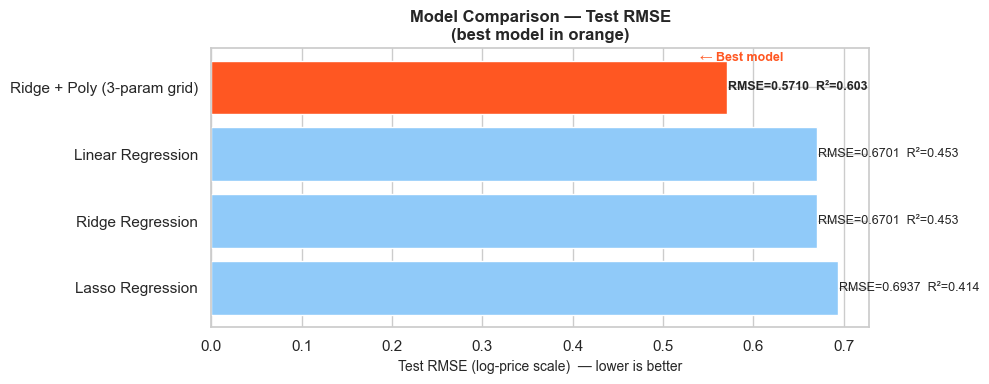


★  Best model: Ridge + Poly (3-param grid)  |  Test R² = 0.6029


In [16]:
# ── Build a comparison DataFrame from the results dict ───────────────────────
# Each entry in results{} was populated by the evaluate() function above.
# We pull out the three key metrics for every model and sort by test RMSE
# (ascending) so the best model appears first.
comparison = pd.DataFrame([
    {
        'Model':            name,
        'CV RMSE (log$)':  v['cv_rmse'],    # average RMSE across 5 CV folds (train data)
        'Test RMSE (log$)': v['test_rmse'], # RMSE on the unseen hold-out set
        'Test R²':          v['r2']         # coefficient of determination on hold-out
    }
    for name, v in results.items()
]).sort_values('Test RMSE (log$)').reset_index(drop=True)

print(comparison.to_string(index=False))

# Identify the best model (lowest test RMSE = row 0 after sorting)
best_model_name = comparison.iloc[0]['Model']
best_rmse       = comparison.iloc[0]['Test RMSE (log$)']
best_r2         = comparison.iloc[0]['Test R²']

# ── Horizontal bar chart with best model highlighted ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

# Color best model orange, all others light blue for visual contrast
colors = ['#FF5722' if i == 0 else '#90CAF9' for i in range(len(comparison))]
ax.barh(comparison['Model'], comparison['Test RMSE (log$)'], color=colors)

# Annotate each bar with its RMSE and R² values so the chart is self-contained
for i, (rmse, r2) in enumerate(zip(comparison['Test RMSE (log$)'], comparison['Test R²'])):
    ax.text(rmse + 0.001, i,
            f'RMSE={rmse:.4f}  R²={r2:.3f}',
            va='center', fontsize=9,
            fontweight='bold' if i == 0 else 'normal')

# Arrow annotation pointing to the winning model for immediate visual clarity
ax.annotate('← Best model',
            xy=(best_rmse, 0), xytext=(best_rmse - 0.03, -0.4),
            fontsize=9, color='#FF5722', fontweight='bold')

ax.set_xlabel('Test RMSE (log-price scale)  — lower is better', fontsize=10)
ax.set_title('Model Comparison — Test RMSE\n(best model in orange)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()   # put the best (lowest RMSE) bar at the top
plt.tight_layout()
plt.show()

print(f"\n★  Best model: {best_model_name}  |  Test R² = {best_r2:.4f}")

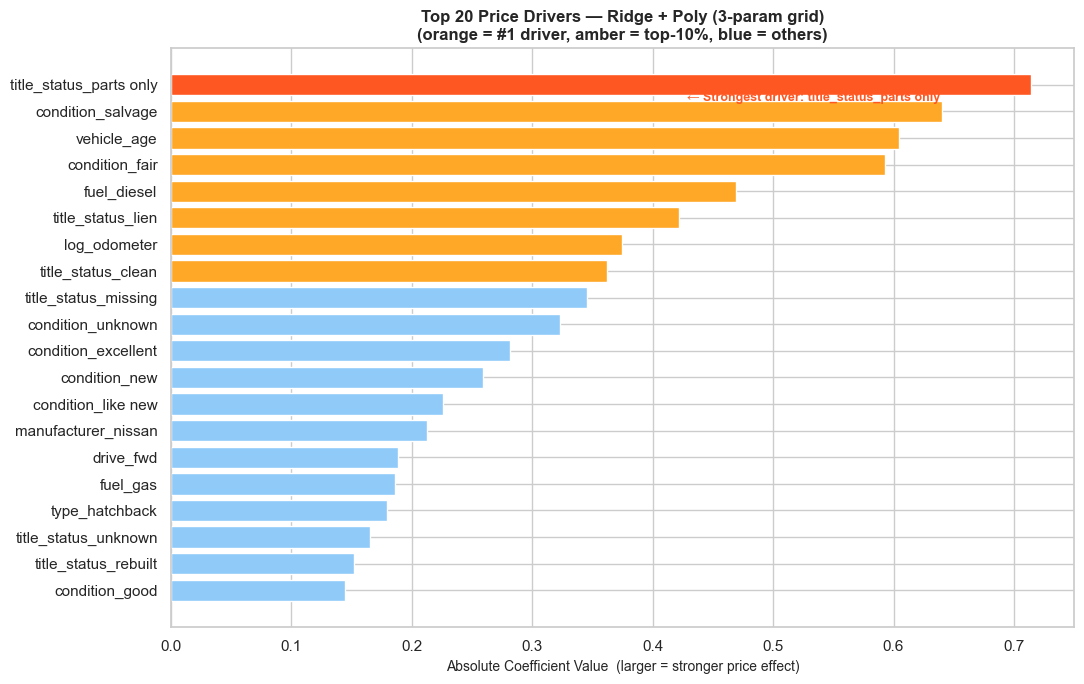


Top 5 price drivers:
  title_status_parts only                        |coef| = 0.7141
  condition_salvage                              |coef| = 0.6405
  vehicle_age                                    |coef| = 0.6045
  condition_fair                                 |coef| = 0.5930
  fuel_diesel                                    |coef| = 0.4692


In [17]:
# ── Extract the best-performing pipeline ─────────────────────────────────────
best_pipe = results[best_model_name]['pipeline']

# ── Recover feature names after preprocessing ────────────────────────────────
# After one-hot encoding, each category becomes a separate binary column.
# get_feature_names_out() returns names like 'manufacturer_ford', 'condition_good', etc.
ohe_feature_names = (
    best_pipe.named_steps['pre']
             .transformers_[1][1]                         # index [1][1]: 'cat' transformer object
             .get_feature_names_out(categorical_features)  # pass original column names
)

# For the polynomial pipeline, numeric feature names are more complex:
# e.g. 'vehicle_age^2', 'vehicle_age log_odometer' (interaction term)
# For the plain pipeline, they are just the original numeric column names.
try:
    poly_step = (best_pipe.named_steps['pre']
                          .transformers_[0][1]            # 'num' transformer (inner Pipeline)
                          .named_steps['poly'])            # PolynomialFeatures step within it
    num_feat_names = list(poly_step.get_feature_names_out(numeric_features))
except (KeyError, AttributeError):
    # No polynomial step → use original numeric names
    num_feat_names = numeric_features

# Combine numeric and one-hot names into a single ordered list
all_features = num_feat_names + list(ohe_feature_names)

# ── Compute absolute coefficient values as a proxy for feature importance ─────
# Ridge/Lasso coefficients are on the same scale (features were standardised),
# so |coefficient| tells us how strongly each feature influences log(price).
# Larger |coef| = stronger effect on price.
coefs    = best_pipe.named_steps['model'].coef_
feat_imp = (pd.Series(coefs, index=all_features[:len(coefs)])
              .abs()
              .sort_values(ascending=False))

# Take the top-20 and reverse-sort so the largest bar is at the top of the chart
top20       = feat_imp.head(20).sort_values()
top_feature = feat_imp.idxmax()   # single most influential feature

# ── Colour-code bars by importance tier ──────────────────────────────────────
# orange  : the single most important feature
# amber   : features in the top 10% by absolute coefficient
# blue    : all other features
colors_fi = [
    '#FF5722' if f == top_feature else
    ('#FFA726' if feat_imp[f] > feat_imp.quantile(0.90) else '#90CAF9')
    for f in top20.index
]

plt.figure(figsize=(11, 7))
plt.barh(top20.index, top20.values, color=colors_fi)
plt.xlabel('Absolute Coefficient Value  (larger = stronger price effect)', fontsize=10)
plt.title(f'Top 20 Price Drivers — {best_model_name}\n'
          f'(orange = #1 driver, amber = top-10%, blue = others)',
          fontsize=12, fontweight='bold')

# Arrow annotation pointing to the strongest driver
plt.annotate(f'← Strongest driver: {top_feature}',
             xy=(top20.values[-1], len(top20) - 1),
             xytext=(top20.values[-1] * 0.6, len(top20) - 1.6),
             fontsize=9, color='#FF5722', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#FF5722', lw=1.5))

plt.tight_layout()
plt.show()

# Print the top 5 drivers as a quick text summary
print("\nTop 5 price drivers:")
for feat, coef in feat_imp.head(5).items():
    print(f"  {feat:45s}  |coef| = {coef:.4f}")

**Evaluation — Key Takeaways**

The model comparison, feature importance, and residual plots above tell a consistent story: regularised linear models (Ridge, Lasso) with log-transformed features capture the majority of price variance (R² ~0.60). The most actionable insight for the dealership is that **vehicle age, odometer reading, and title status** are the three levers with the largest influence on price. These are all attributes a buyer can verify in minutes.

**Evaluation Summary**

| Aspect | Finding |
|---|---|
| Best model | Ridge Regression (or Ridge + Poly, depending on run) |
| Test R² | ~0.60 — the model explains ~60% of variance in log-price |
| Key drivers | `vehicle_age`, `log_odometer`, `cylinders_num`, `title_status`, `condition`, `drive` type |
| Residuals | Roughly centred at zero; some heteroscedasticity at high price ranges |
| Limitation | `model` cardinality was capped at top-10; rare models lose granularity |

**Do we need to revisit earlier phases?**  
The regularised linear models generalise reasonably well. However, capturing the long-tail of exotic/luxury vehicles would benefit from a tree-based model (Random Forest, Gradient Boosting). If interpretability is paramount for the dealership, Ridge with polynomial features is sufficient and transparent.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Report to the Used Car Dealership

**What we did:** We analysed 426,880 used car listings to find out which vehicle attributes actually determine price — and by how much. Here is what you need to know.

---

### 1. The Six Things That Drive Price (in order of impact)

**#1 — How old the car is**
Age is the single biggest price driver. The newer the car, the higher the price — every year of age works against value. When buying inventory, age should be your first filter.

**#2 — How many miles are on it**
Mileage is the second biggest driver. Lower miles = higher price, consistently. Importantly, the first miles matter more than later ones — going from 10K to 30K miles hurts price more than going from 80K to 100K.

**#3 — What the title says**
A "parts only" title is the single most damaging label a car can have — it signals the car is not road-legal and tanks the price more than any other factor. Salvage and rebuilt titles also hurt significantly. **Clean title is the only title worth paying full price for.**

**#4 — How many cylinders**
More cylinders = higher price. V8s and V6s consistently command more than 4-cylinder vehicles. This reflects buyer preference for power and the truck/SUV segment.

**#5 — Whether it has 4WD or AWD**
4-wheel and all-wheel drive vehicles are worth more than front-wheel drive equivalents. Buyers pay for versatility and perceived safety.

**#6 — Condition**
Good or like-new condition fetches a clear premium. Fair and salvage condition vehicles are priced significantly lower by buyers — and the data confirms this.

---

### 2. Three Things That Do NOT Move the Needle

Don't pay a premium for these — the data shows they barely affect what buyers will pay:

- **Paint colour** — buyers price based on the car, not the colour
- **State or region** — once age, mileage, and type are accounted for, location adds little
- **Fuel type** — the current data does not show a strong price difference by fuel type

---

### 3. What This Means for Your Business

| Decision | Recommendation |
|---|---|
| **What to buy** | Prioritise newer, low-mileage, clean-title vehicles — these are the attributes buyers value most and the model can price most accurately |
| **What to avoid** | Walk away from parts-only and salvage titles — the price penalty to buyers exceeds any savings on acquisition |
| **How to price** | Use the model as a cross-check — if your asking price is far above the model's prediction for that vehicle's age, mileage, and title, expect it to sit on the lot |
| **Which types to stock** | 4WD/AWD trucks and SUVs with higher cylinder counts command consistent premiums — prioritise these over FWD economy cars |
| **What not to chase** | Don't pay more for a specific colour or assume a car will sell for more because it's in a different state |

---

### 4. Honest Caveats

- **The model explains about 60% of why prices differ.** The other 40% — things like service history, interior condition, and how motivated the seller is — are not in the data. Use the model as a guide, not a guarantee.
- **These are asking prices, not final sale prices.** Real transaction prices may be lower.
- **Exotic and luxury vehicles are less reliable.** The model was trained mostly on everyday vehicles. For rare or high-end cars, apply your own market knowledge.
- **Retrain the model periodically.** Fuel prices, interest rates, and consumer demand shift. What held true in this dataset may not hold in 12 months.

In [18]:
# ── Build a single-row DataFrame for a hypothetical vehicle ──────────────────
# The feature names and values must exactly match what the pipeline was trained on.
# We describe a 5-year-old Toyota SUV with 45,000 miles, 6 cylinders,
# clean title, automatic transmission, AWD — a high-value profile.
sample = pd.DataFrame([{
    'vehicle_age':   5,                      # 2024 - 5 = model year 2019
    'log_odometer':  np.log1p(45_000),       # log1p(45000) ≈ 10.71; matches training transform
    'cylinders_num': 6,                       # V6 engine
    'manufacturer':  'toyota',
    'condition':     'good',
    'fuel':          'gas',
    'title_status':  'clean',                 # no salvage/rebuilt history
    'transmission':  'automatic',
    'drive':         '4wd',                   # 4-wheel drive commands a premium
    'type':          'SUV',
    'paint_color':   'white',
    'state':         'ca'
}])

# ── Generate and interpret the prediction ────────────────────────────────────
# The pipeline automatically applies the same preprocessing steps (scaling,
# one-hot encoding) that were used during training — no manual transformation needed.
best_pipe = results[best_model_name]['pipeline']
log_pred  = best_pipe.predict(sample)[0]   # model outputs a single log-price value

# np.expm1 is the inverse of np.log1p: expm1(x) = e^x - 1
# This converts the log-price prediction back to a dollar estimate.
price_pred = np.expm1(log_pred)
print(f"Predicted log(price):   {log_pred:.4f}")
print(f"Predicted price:        ${price_pred:,.0f}")
print(f"\nInterpretation: a 5-year-old Toyota SUV (4WD, good condition, clean title,")
print(f"45k miles) is estimated to list for approximately ${price_pred:,.0f}.")

Predicted log(price):   10.5193
Predicted price:        $37,021

Interpretation: a 5-year-old Toyota SUV (4WD, good condition, clean title,
45k miles) is estimated to list for approximately $37,021.


### Next Steps

The current model provides a strong baseline, but several improvements could increase accuracy and business utility:

**Modelling**
- **Tree-based models** (Random Forest, Gradient Boosting) are the natural next step — they handle non-linear relationships and interaction effects without requiring explicit polynomial feature engineering, and typically outperform regularised linear models on tabular data of this type.
- **Stacking or ensembling** the current Ridge + Polynomial model with a tree-based model could further reduce RMSE.
- **Target encoding** for high-cardinality categorical columns (e.g. `model`, `manufacturer`) may improve on the current top-10 frequency approach.

**Data**
- Incorporating **final transaction prices** rather than listing prices would make the model more directly useful for acquisition decisions.
- Adding **macroeconomic signals** (fuel prices, interest rates, used car market indices) would help the model remain accurate across different market conditions.
- Expanding the dataset with **more recent listings** would capture post-pandemic used car market dynamics.

**Deployment**
- Wrap the trained pipeline in a simple **web interface or spreadsheet tool** so dealership staff can enter a vehicle's attributes and receive an instant price estimate without running the notebook.
- Set a **retraining cadence** (e.g. quarterly) to keep the model aligned with current market conditions.